In [1]:
import pandas as pd

df = pd.read_csv('../data/employee_attrition_clean.csv')  

Performance_Score: anyone scoring 85 or above is labeled "high performer" (1), everyone else is 0. value_counts() checks the class balance of this new target.

In [ ]:
df['Performance'] = (df['Performance_Score'] >= 85).astype(int)
print(df['Performance'].value_counts())

Performance
0    846
1    124
Name: count, dtype: int64


In [3]:
X = df.drop(columns=['Attrition', 'Employee_ID', 'Join_Date', 
                       'Performance_Score', 'Performance'], errors='ignore')
department_cols = [col for col in X.columns if col.startswith('Department_')]
X = X.drop(columns=department_cols)

y = df['Performance']

Train/test split, SMOTE, and scaling 

In [4]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('Before SMOTE:')
print(y_train.value_counts())
print('\n After SMOTE:')
print(y_train_resampled.value_counts())


Col = ['Age', 'Years_At_Company', 'Monthly_Income'] 
scaler = StandardScaler()
X_train_resampled[Col] = scaler.fit_transform(X_train_resampled[Col])
X_test[Col] = scaler.transform(X_test[Col])


Before SMOTE:
Performance
0    677
1     99
Name: count, dtype: int64

 After SMOTE:
Performance
0    677
1    677
Name: count, dtype: int64


SVM decision boundaries depend heavily on the kernel choice:

Linear assumes classes are separable by a straight line/hyperplane. 

RBF (Gaussian) can capture more complex, non-linear boundaries.  

Polynomial (degree 3) captures curved boundaries with a specific polynomial shape

In [5]:
# report and coffusion matrix
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Linear 
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train_resampled, y_train_resampled)
pred_linear = svm_linear.predict(X_test)

# RBF 
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf.fit(X_train_resampled, y_train_resampled)
pred_rbf = svm_rbf.predict(X_test)

# Polynomial 
svm_poly = SVC(kernel='poly', degree=3, probability=True, random_state=42)
svm_poly.fit(X_train_resampled, y_train_resampled)
pred_poly = svm_poly.predict(X_test)

print("=== Linear Kernel ===")
print(classification_report(y_test, pred_linear))

print("=== RBF Kernel ===")
print(classification_report(y_test, pred_rbf))

print("=== Polynomial Kernel (degree=3) ===")
print(classification_report(y_test, pred_poly))

=== Linear Kernel ===
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       169
           1       0.21      0.16      0.18        25

    accuracy                           0.81       194
   macro avg       0.55      0.54      0.54       194
weighted avg       0.79      0.81      0.80       194

=== RBF Kernel ===
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       169
           1       0.19      0.12      0.15        25

    accuracy                           0.82       194
   macro avg       0.53      0.52      0.52       194
weighted avg       0.79      0.82      0.80       194

=== Polynomial Kernel (degree=3) ===
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       169
           1       0.15      0.24      0.19        25

    accuracy                           0.73       194
   macro avg       0.52      0.52      0.51       

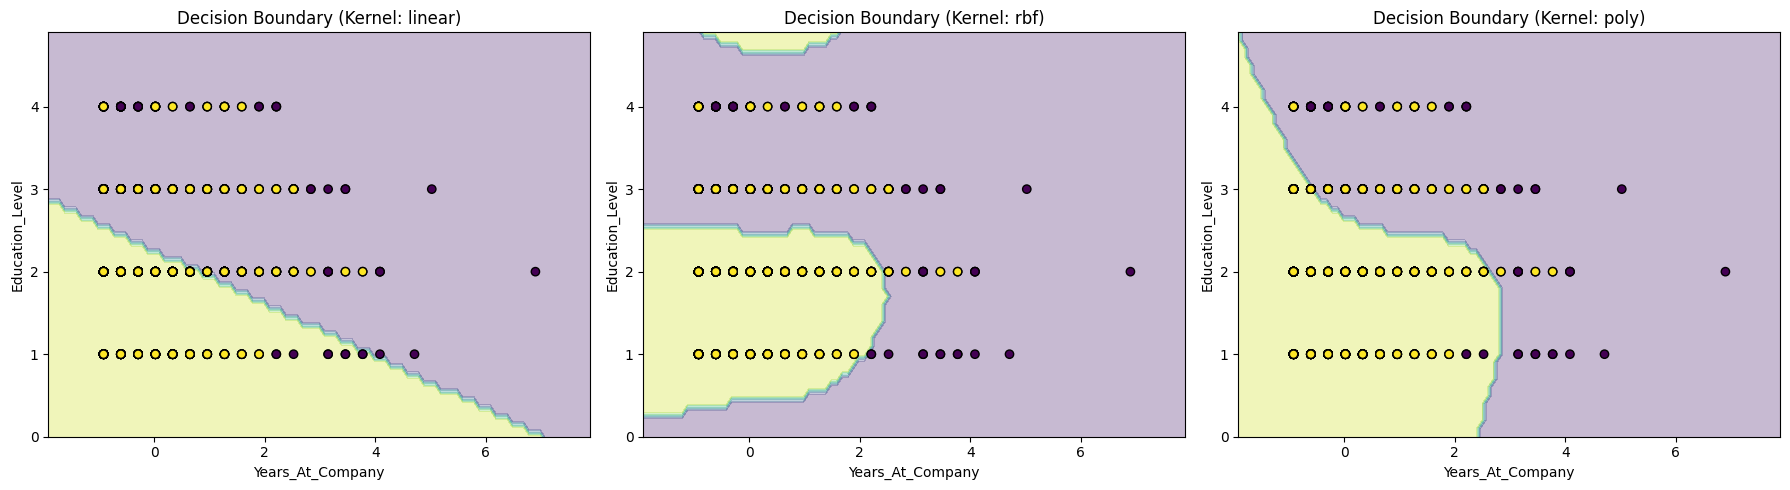

In [6]:
feature_x = 'Years_At_Company'
feature_y = 'Education_Level'

X_train_2d = X_train_resampled[[feature_x, feature_y]].values
y_train_2d = y_train_resampled

kernels = ['linear', 'rbf', 'poly']
models_2d = {}
for kernel in kernels:
    model = SVC(kernel=kernel, degree=3, random_state=42)
    model.fit(X_train_2d, y_train_2d)   
    models_2d[kernel] = model

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(18, 5))
for i, kernel in enumerate(kernels):
    model = models_2d[kernel]
    plt.subplot(1, 3, i + 1)

    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                          np.arange(y_min, y_max, 0.1))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_2d,
                edgecolors='k', marker='o')
    plt.title(f"Decision Boundary (Kernel: {kernel})")
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)

plt.tight_layout()
plt.show()

## Talent Identification — Summary

Tested 3 SVM kernels (Linear, RBF, Polynomial) to predict future high performers, 
using background attributes only (Performance_Score excluded to avoid leakage).

| Kernel | Recall |  | Accuracy |
| Linear | 0.16   |  |    0.81  |
| RBF    | 0.12   |  |    0.82  |
| Poly   | 0.24   |  |    0.73  |

Chosen: Polynomial — catches more real high-potential employees (higher recall), which matters more than overall accuracy for early talent detection.

In [7]:
X_full = X.copy()
X_full[Col] = scaler.transform(X_full[Col])
df['High_Potential_Flag'] = svm_poly.predict(X_full)
df[['Employee_ID','High_Potential_Flag']].to_csv('../data/q3_output.csv', index=False)